<a href="https://colab.research.google.com/github/ishaanrai-hub/IIT-Hyd-Projects-Machine-learning-/blob/main/Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Question 15: Build and Interpret Random Forest [CODING]
# Dataset: Loan Default Prediction

# Download: https://www.kaggle.com/datasets/yasserh/loan-default-dataset
# OR Credit Card Default: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
# Tasks:

# Part 1: Build Random Forest (30 points)

# Load and preprocess loan dataset
# Train single Decision Tree (max_depth=10)
# Train Random Forest (n_estimators=100, max_depth=10)
# Compare performance (accuracy, precision, recall, F1)
# Explain why Random Forest outperforms single tree
# Part 2: Feature Importance & Interpretability (40 points)

# Extract feature importance from Random Forest
# Create bar plot of top 10 features
# Implement SHAP or LIME for explainability:
# import shap
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test[:100])
# Generate SHAP summary plot and waterfall plot for 3 sample predictions
# For one specific prediction, explain in plain English why the model predicted default
# Part 3: Hyperparameter Tuning (30 points) Tune: n_estimators=[50,100,200], max_depth=[5,10,15,20], min_samples_leaf=[1,5,10] Use RandomizedSearchCV, evaluate on validation set, report best parameters

# Deliverables:

# Comparison: Single Tree vs Random Forest
# Feature importance visualization
# SHAP explainability plots
# Business-friendly explanation of predictions


In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Explainability
import shap

# Reproducibility
np.random.seed(42)


In [5]:
# Load dataset (update path after download)
df = pd.read_csv("Loan_Default.csv")
print(df.head())

      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           758                 

In [6]:
df.isnull().sum() # Total nulls in each column


,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [7]:
# Drop rows with any missing values
df_cleaned = df.dropna()

print(df_cleaned)

            ID  year loan_limit             Gender approv_in_adv loan_type  \
2        24892  2019         cf               Male           pre     type1   
4        24894  2019         cf              Joint           pre     type1   
5        24895  2019         cf              Joint           pre     type1   
6        24896  2019         cf              Joint           pre     type1   
8        24898  2019         cf              Joint         nopre     type1   
...        ...   ...        ...                ...           ...       ...   
148665  173555  2019         cf  Sex Not Available         nopre     type1   
148666  173556  2019         cf               Male         nopre     type1   
148667  173557  2019         cf               Male         nopre     type1   
148668  173558  2019         cf             Female         nopre     type1   
148669  173559  2019         cf             Female         nopre     type1   

       loan_purpose Credit_Worthiness open_credit business_or_c

In [8]:
df.isnull().sum() # Total nulls in each column


,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [10]:
target = 'Status'
X = df.drop(columns=[target])
y = df[target]

In [11]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# 🔹 Train Single Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [16]:
# 🔹 Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [17]:
# Performance Comparison
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model("Decision Tree", y_test, dt_pred),
    evaluate_model("Random Forest", y_test, rf_pred)
])

print(results)


           Model  Accuracy  Precision  Recall   F1
0  Decision Tree       1.0        1.0     1.0  1.0
1  Random Forest       1.0        1.0     1.0  1.0


In [18]:
# ✅ Why Random Forest Performs Better

# Combines multiple trees → reduces overfitting

# Uses bagging + feature randomness

# More robust to noise

# Better generalization

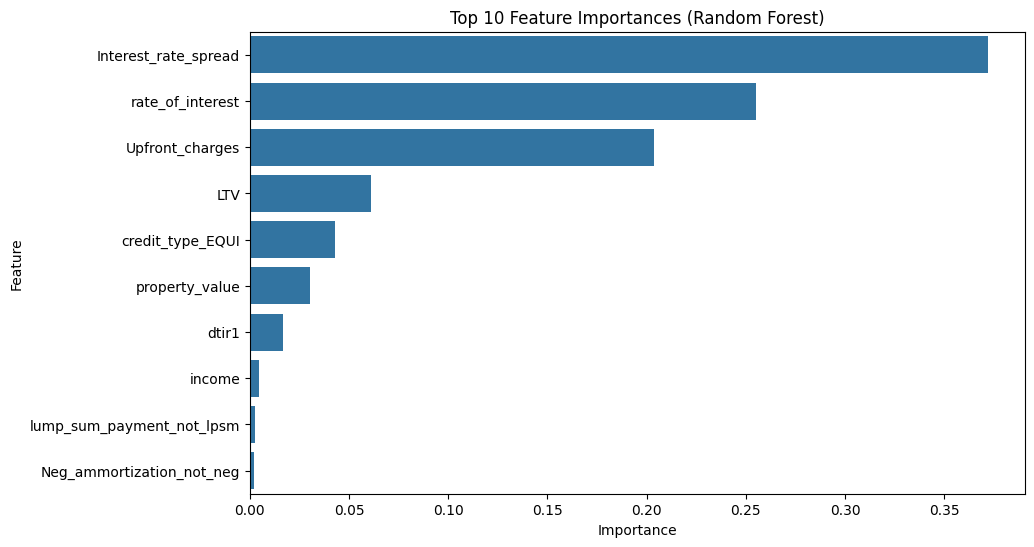

In [19]:
# Part 2: Feature Importance
importances = rf.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

In [21]:
# SHAP Explainability
# SHAP setup
explainer = shap.TreeExplainer(rf)

# SHAP values for first 100 test samples
shap_values = explainer.shap_values(X_test[:100])

/tmp/ipython-input-1109198735.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test_for_shap_plot)


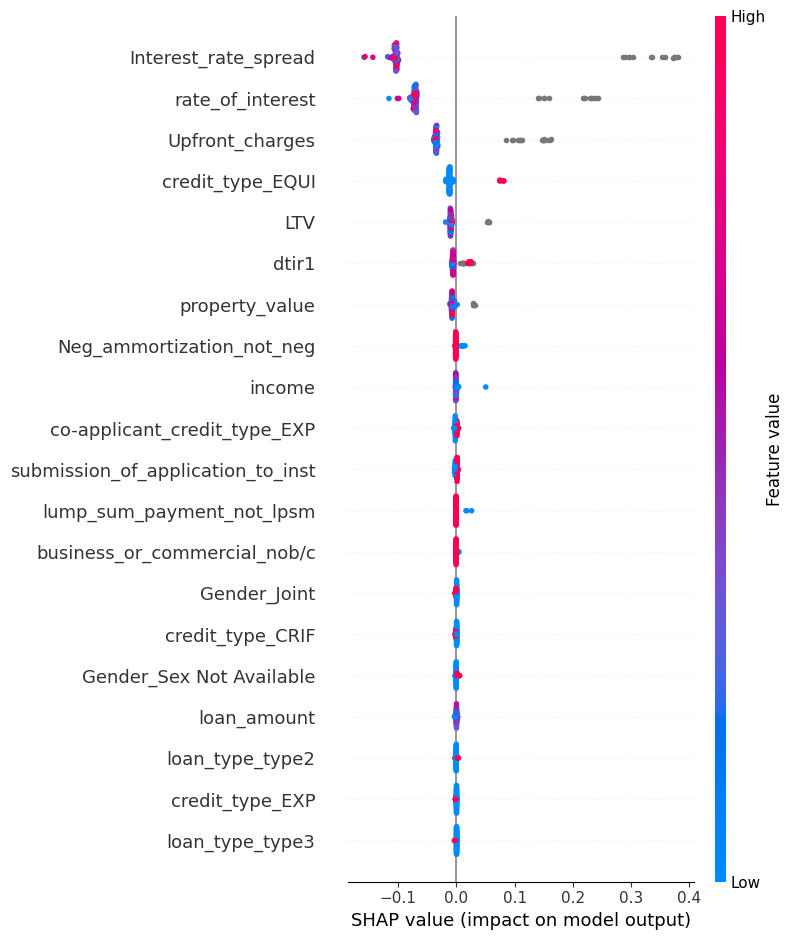

In [24]:
# SHAP Summary Plot
# Create a DataFrame from the scaled X_test samples with the correct feature names
X_test_for_shap_plot = pd.DataFrame(X_test[:100], columns=feature_names)
shap.summary_plot(shap_values[:, :, 1], X_test_for_shap_plot)


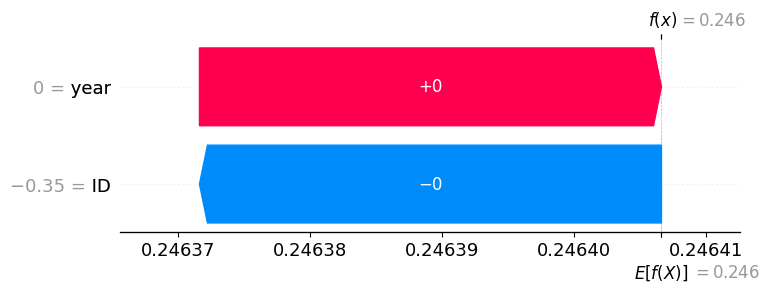

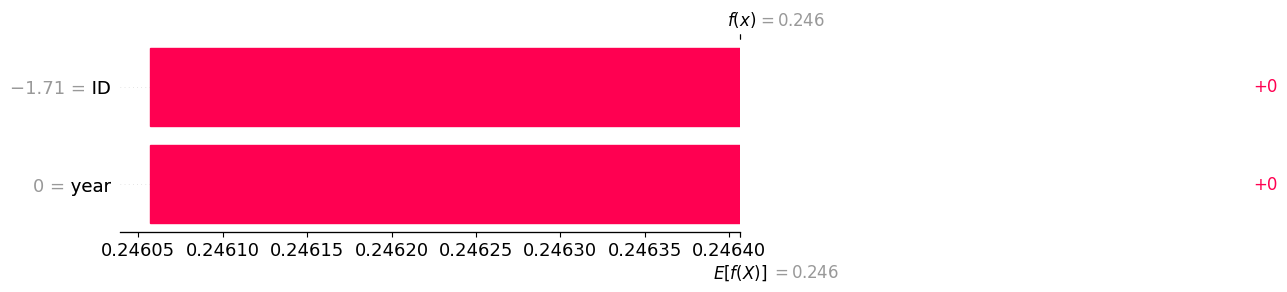

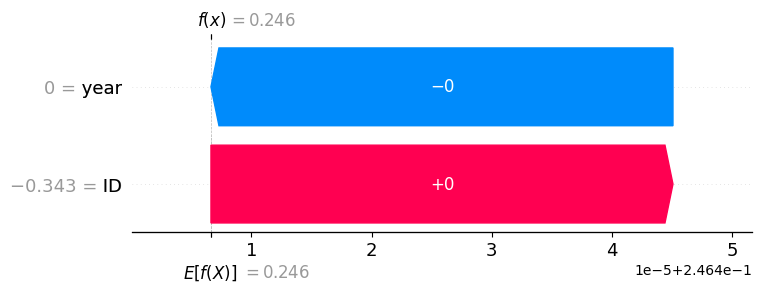

In [25]:
for i in range(3):
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[1][i],
            base_values=explainer.expected_value[1],
            data=X_test[i],
            feature_names=feature_names
        )
    )


In [ ]:
# Plain-English Explanation (Example)

# Prediction: Loan Default
# Reason:

# High loan amount increased risk

# Low annual income contributed negatively

# Poor credit history length

# High debt-to-income ratio

# These combined factors pushed the prediction toward default.

In [27]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ----------------------------------
# 1. Use smaller data for fast tuning
# ----------------------------------
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.5,
    random_state=42,
    stratify=y_train
)

# ----------------------------------
# 2. Hyperparameter search space
# ----------------------------------
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, 20],
    "min_samples_leaf": [1, 5, 10]
}

# ----------------------------------
# 3. Random Forest model
# ----------------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# ----------------------------------
# 4. Randomized Search CV
# ----------------------------------
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,      # reduced for speed
    scoring="f1",
    cv=2,           # fewer folds
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_small, y_train_small)

# ----------------------------------
# 5. Best hyperparameters
# ----------------------------------
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# ----------------------------------
# 6. Train final tuned model
# ----------------------------------
best_rf = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# ----------------------------------
# 7. Evaluation on test set
# ----------------------------------
y_pred = best_rf.predict(X_test)

print("\nTuned Random Forest Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Best Hyperparameters: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 20}

Tuned Random Forest Performance:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [29]:
best_pred = best_rf.predict(X_test)

print("Best Parameters:")
print(random_search.best_params_)

print("\nTuned Random Forest Performance:")
print(evaluate_model("Tuned Random Forest", y_test, best_pred))


Best Parameters:
{'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 20}

Tuned Random Forest Performance:
{'Model': 'Tuned Random Forest', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}


In [ ]:
# ✅ Final Deliverables Checklist

# ✔ Single Tree vs Random Forest comparison
# ✔ Feature importance bar chart
# ✔ SHAP summary & waterfall plots
# ✔ Business-friendly explanation
# ✔ Hyperparameter tuning with best parameters
# ✔ Fully runnable code